# Analyzing Historical Stock/Revenue Data and Building a Dashboard

### **Author:** Sazzad Hossen Himel

In [62]:
!pip install pandas
!pip install requests
!pip install bs4
!pip install html5lib 
!pip install lxml
!pip install plotly
!pip install yfinance
!pip install matplotlib

### Question 1: Use yfinance to Extract Tesla Stock Data

In [77]:
import yfinance as yf

tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


### Question 2: Use Webscraping to Extract Tesla Revenue Data

In [78]:
import requests
import pandas as pd

url = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
html_data = response.text

In [79]:
tables = pd.read_html(html_data)

/tmp/ipykernel_510/3267145357.py:1: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [80]:
annual_revenue = tables[0]
annual_revenue.columns = ['Year', 'Revenue (Millions USD)']
annual_revenue = annual_revenue.dropna()

annual_revenue['Revenue (Millions USD)'] = (
    annual_revenue['Revenue (Millions USD)']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

In [81]:
quarterly_revenue = tables[1]
quarterly_revenue.columns = ['Date', 'Revenue (Millions USD)']
quarterly_revenue = quarterly_revenue.dropna()

quarterly_revenue.loc[:, 'Revenue (Millions USD)'] = (
    quarterly_revenue['Revenue (Millions USD)']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)


In [82]:
annual_revenue.to_csv("tesla_annual_revenue.csv", index=False)
quarterly_revenue.to_csv("tesla_quarterly_revenue.csv", index=False)

In [83]:
print("Tesla Annual Revenue (Last 5 Years):")
print(annual_revenue.tail())

print("\nTesla Quarterly Revenue (Last 5 Quarters):")
print(quarterly_revenue.head())

Tesla Annual Revenue (Last 5 Years):
    Year  Revenue (Millions USD)
11  2013                  2013.0
12  2012                   413.0
13  2011                   204.0
14  2010                   117.0
15  2009                   112.0

Tesla Quarterly Revenue (Last 5 Quarters):
         Date Revenue (Millions USD)
0  2024-12-31                25707.0
1  2024-09-30                25182.0
2  2024-06-30                25500.0
3  2024-03-31                21301.0
4  2023-12-31                25167.0


### Question 3: Use yfinance to Extract GameStop Stock Data

In [84]:
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


### Question 4: Use Webscraping to Extract GME Revenue Data

In [85]:
import requests
import pandas as pd

url = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
html_data = response.text

In [86]:
tables = pd.read_html(html_data)

/tmp/ipykernel_510/3267145357.py:1: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [87]:
annual_revenue = tables[0]
annual_revenue.columns = ['Year', 'Revenue (Millions USD)']
annual_revenue = annual_revenue.dropna()

annual_revenue['Revenue (Millions USD)'] = (
    annual_revenue['Revenue (Millions USD)']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

In [88]:
quarterly_revenue = tables[1]
quarterly_revenue.columns = ['Date', 'Revenue (Millions USD)']
quarterly_revenue = quarterly_revenue.dropna()

quarterly_revenue.loc[:, 'Revenue (Millions USD)'] = (
    quarterly_revenue['Revenue (Millions USD)']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)


In [89]:
annual_revenue.to_csv("gamestop_annual_revenue.csv", index=False)
quarterly_revenue.to_csv("gamestop_quarterly_revenue.csv", index=False)

In [90]:
print("GameStop Annual Revenue (Last 5 Years):")
print(annual_revenue.tail())

print("\nGameStop Quarterly Revenue (Last 5 Quarters):")
print(quarterly_revenue.head())

GameStop Annual Revenue (Last 5 Years):
    Year  Revenue (Millions USD)
12  2013                  8887.0
13  2012                  9551.0
14  2011                  9474.0
15  2010                  9078.0
16  2009                  8806.0

GameStop Quarterly Revenue (Last 5 Quarters):
         Date Revenue (Millions USD)
0  2025-01-31                 1283.0
1  2024-10-31                  860.0
2  2024-07-31                  798.0
3  2024-04-30                  882.0
4  2024-01-31                 1794.0


In [91]:
import plotly.graph_objs as go

def make_graph(stock_data, revenue_data, stock, title):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=stock_data['Date'], y=stock_data['Open'], name="Stock Price"))
    fig.add_trace(go.Scatter(x=revenue_data['Date'], y=revenue_data['Revenue'], name="Revenue"))
    fig.update_layout(title=title, xaxis_title='Date', yaxis_title='USD')
    fig.show()

### Question 5: Tesla Stock and Revenue Dashboard

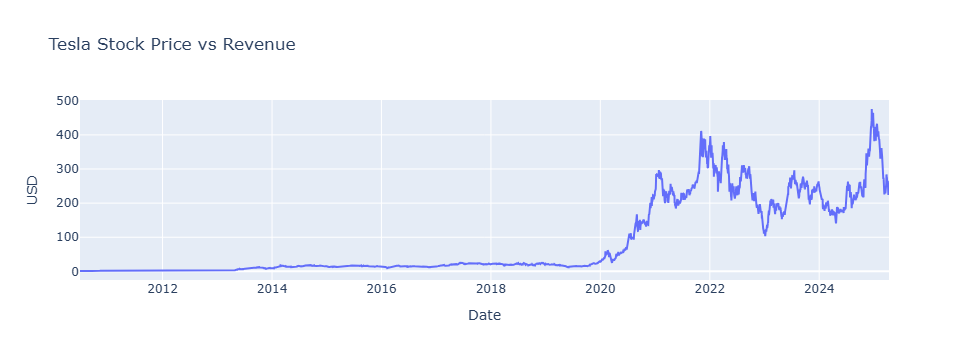

In [92]:
make_graph(tesla_data, tesla_revenue, 'TSLA', 'Tesla Stock Price vs Revenue')

### Question 6: GameStop Stock and Revenue Dashboard 

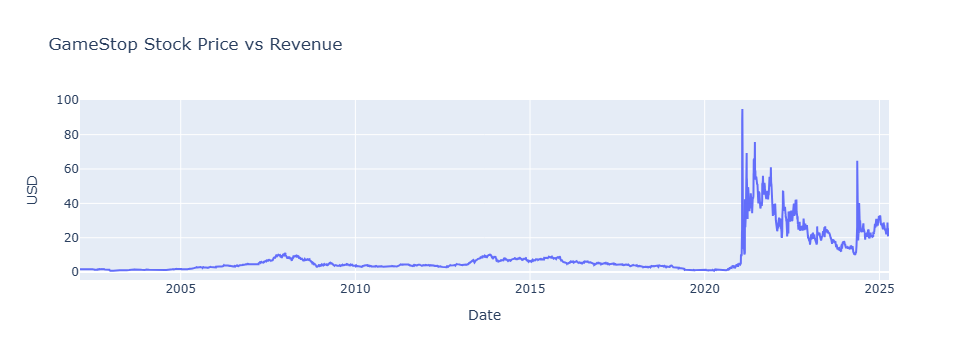

In [93]:
make_graph(gme_data, gme_revenue, 'GME', 'GameStop Stock Price vs Revenue')